0:	learn: 2.5316683	test: 2.5799771	best: 2.5799771 (0)	total: 1.91ms	remaining: 381ms
50:	learn: 1.5873396	test: 1.6337165	best: 1.6337165 (50)	total: 106ms	remaining: 309ms
100:	learn: 1.1105519	test: 1.1495934	best: 1.1495934 (100)	total: 238ms	remaining: 233ms
150:	learn: 0.8316486	test: 0.8640485	best: 0.8640485 (150)	total: 317ms	remaining: 103ms
199:	learn: 0.6524716	test: 0.6803324	best: 0.6803324 (199)	total: 389ms	remaining: 0us

bestTest = 0.6803324448
bestIteration = 199



c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(



🔹 CatBoost Elongation Regression Metrics:
✅ R²: 0.9336
✅ RMSE: 0.6740
✅ MAE: 0.4054
✅ MAPE: 2.70%


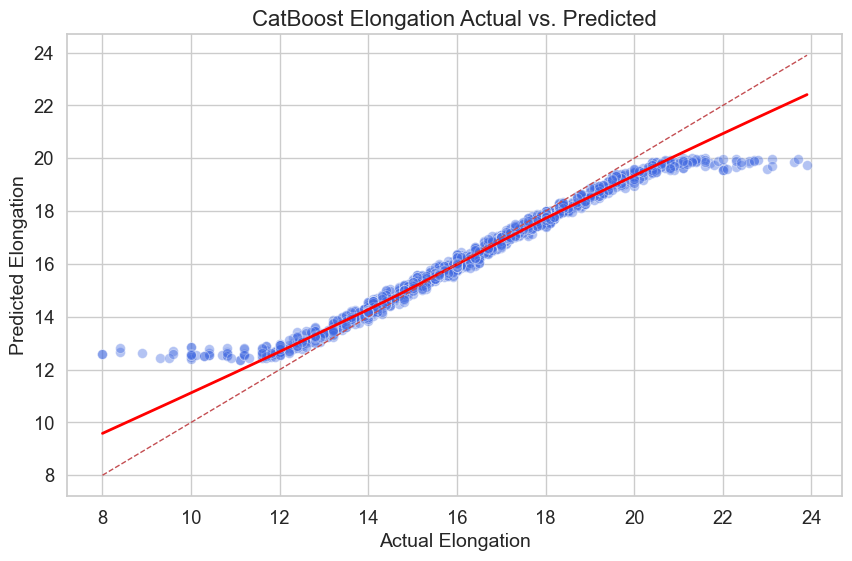

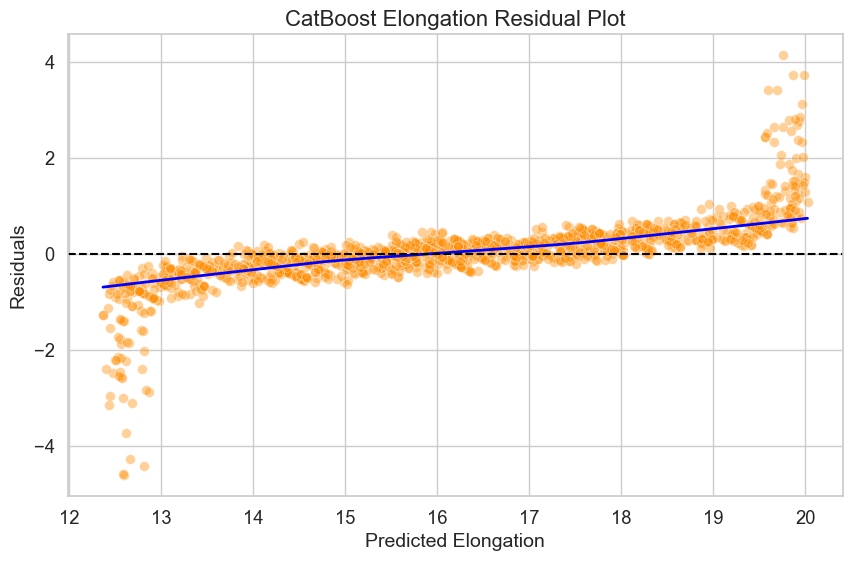

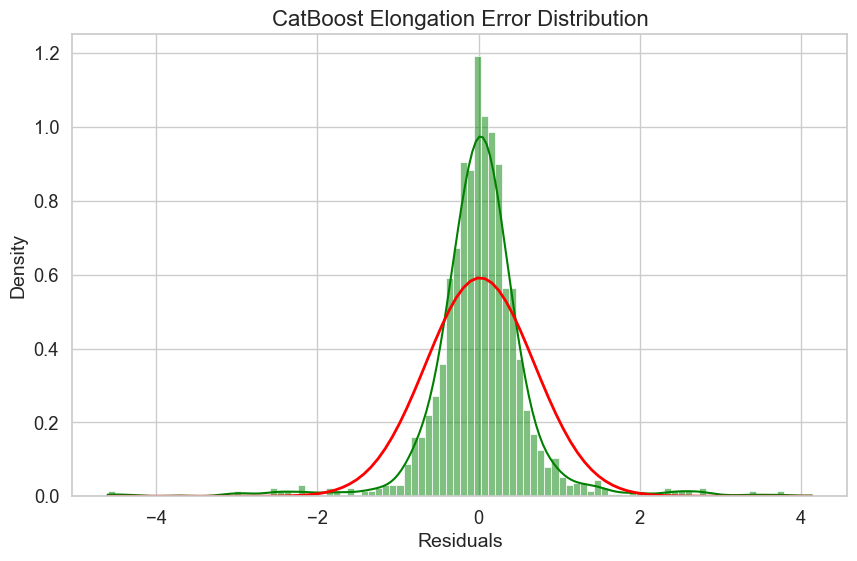

{'learn': {'RMSE': [2.531668295162735, 2.528764646611344, 2.4946860075253494, 2.4672064235571947, 2.432491614856905, 2.4052080376338267, 2.372901195938039, 2.346898419217438, 2.3441680762976667, 2.3184733245875724, 2.3158110908270535, 2.2908567950131333, 2.2603523180622576, 2.2298588985615995, 2.206277254041386, 2.1759978934810675, 2.173973593295228, 2.1512823765167575, 2.1226962204971, 2.1010758401449556, 2.0797728061586205, 2.0589133867176073, 2.0381874936825626, 2.010365323795918, 1.990482103209262, 1.9890464441280447, 1.962414704415453, 1.960284613132994, 1.9331283841762552, 1.9143906516412679, 1.8959639641490478, 1.8776879690826556, 1.8750816258422895, 1.8509730446524613, 1.848474615016066, 1.8225142311642324, 1.8052360265369494, 1.7884265276072744, 1.7718598934459118, 1.748069343114119, 1.7247181374600222, 1.7016676178678525, 1.686255582928595, 1.6711134333470876, 1.6692708890875065, 1.65422084833103, 1.6392435689128544, 1.6245393447209024, 1.6029929347853977, 1.5891698649281163,

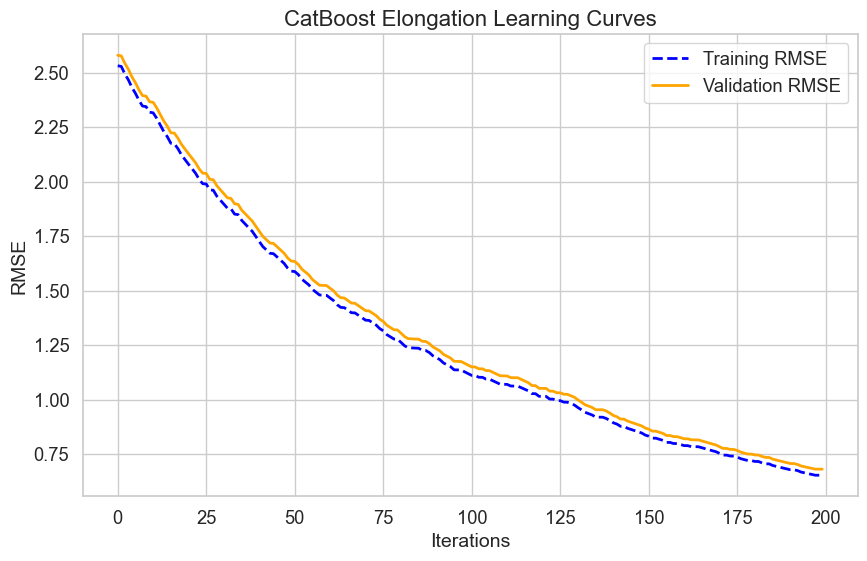

0:	learn: 2.5446846	test: 2.5929264	best: 2.5929264 (0)	total: 2.06ms	remaining: 410ms
50:	learn: 1.9437438	test: 1.9919220	best: 1.9919220 (50)	total: 105ms	remaining: 307ms
100:	learn: 1.5570355	test: 1.6030789	best: 1.6030789 (100)	total: 232ms	remaining: 227ms
150:	learn: 1.2874977	test: 1.3295800	best: 1.3295800 (150)	total: 350ms	remaining: 114ms
199:	learn: 1.0867657	test: 1.1256952	best: 1.1256952 (199)	total: 478ms	remaining: 0us

bestTest = 1.125695173
bestIteration = 199

0:	learn: 2.4799894	test: 2.5285664	best: 2.5285664 (0)	total: 2.32ms	remaining: 462ms
50:	learn: 0.8030755	test: 0.8339624	best: 0.8339624 (50)	total: 106ms	remaining: 309ms
100:	learn: 0.4035837	test: 0.4258288	best: 0.4258288 (100)	total: 177ms	remaining: 173ms
150:	learn: 0.2428471	test: 0.2610048	best: 0.2610048 (150)	total: 243ms	remaining: 78.8ms
199:	learn: 0.1673765	test: 0.1810593	best: 0.1810593 (199)	total: 344ms	remaining: 0us

bestTest = 0.1810593053
bestIteration = 199

0:	learn: 2.4005527	te

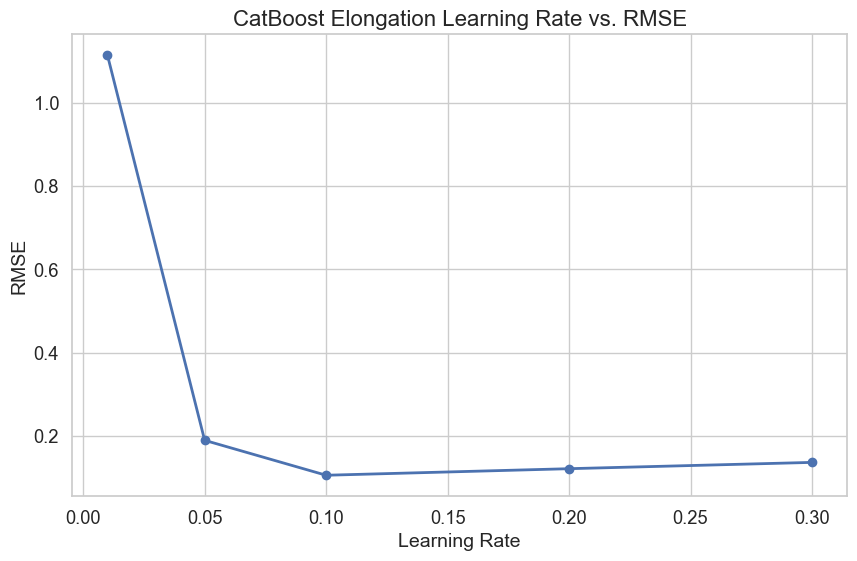

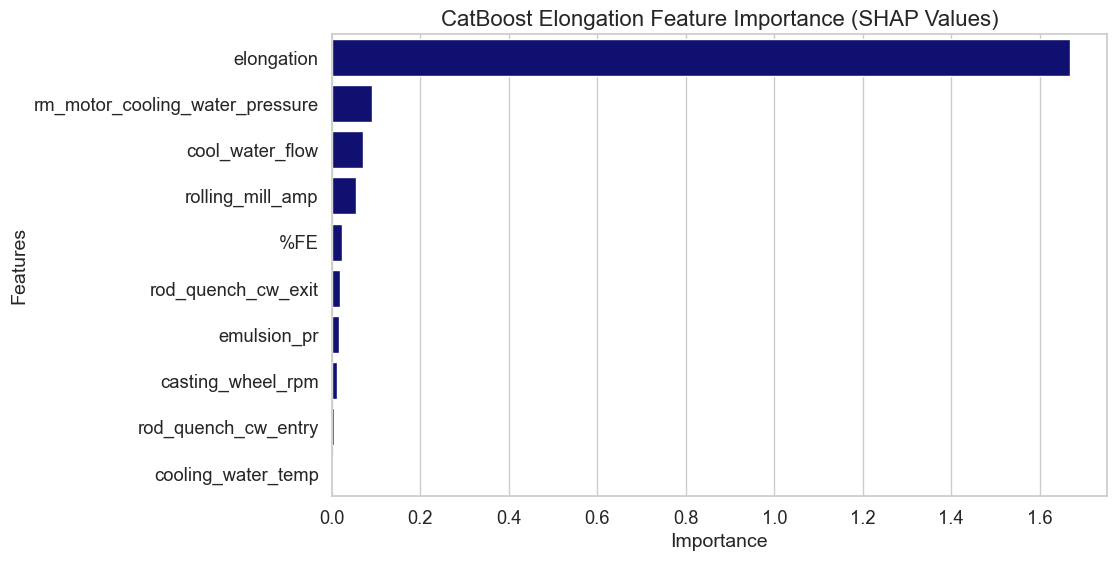

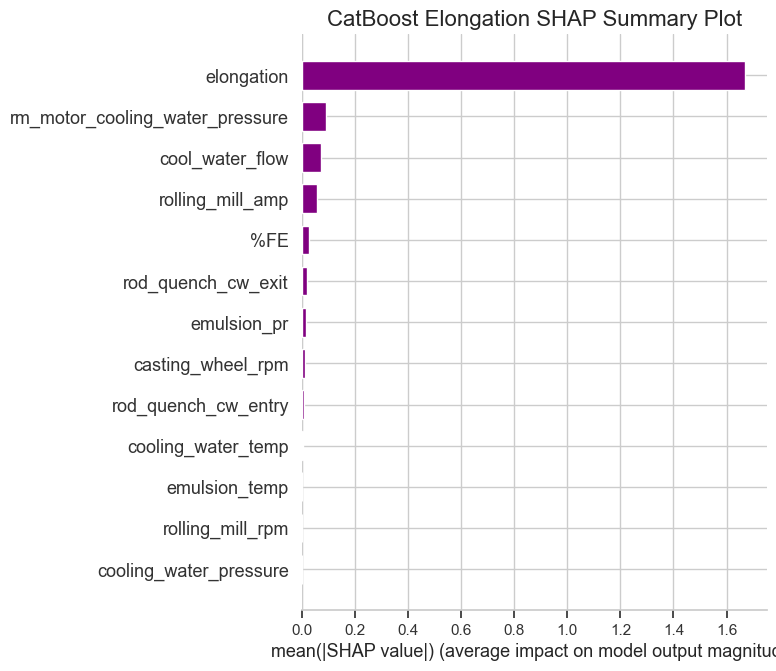

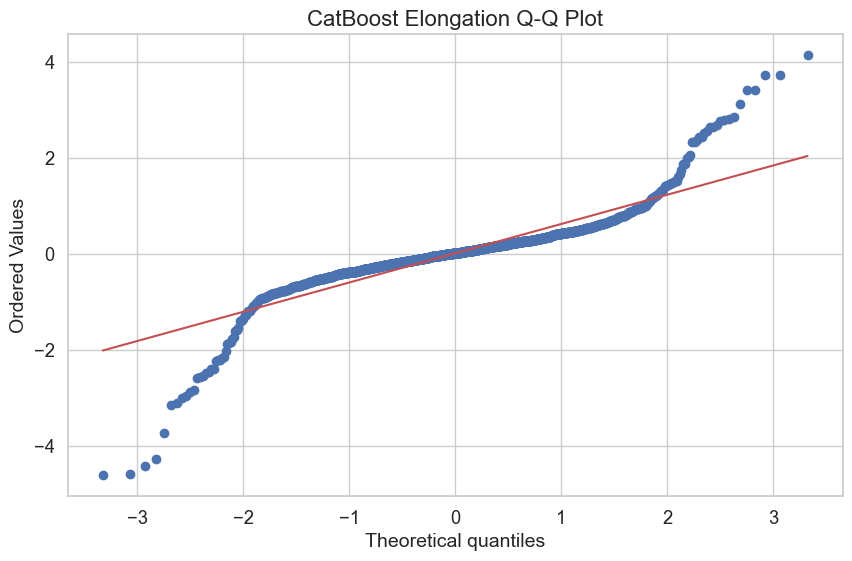

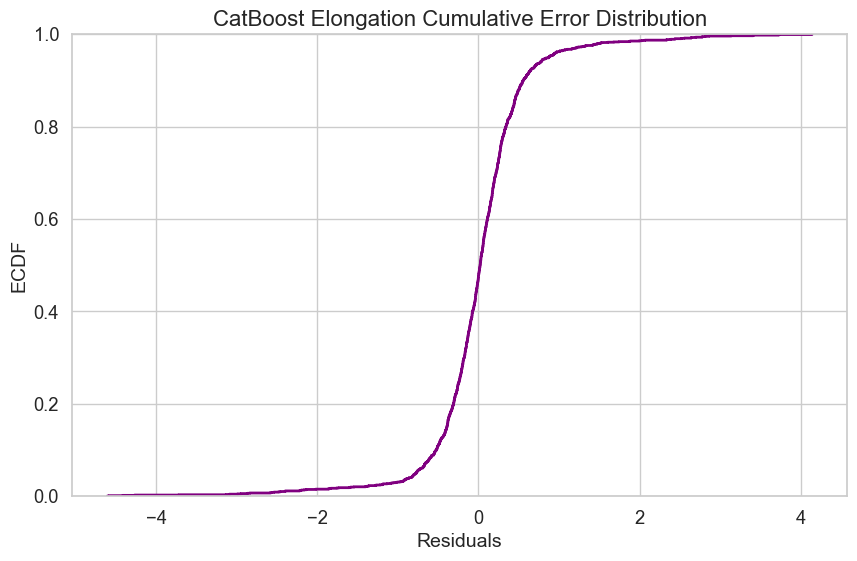

In [2]:
import pandas as pd
import numpy as np
import catboost as cb
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import scipy.stats as stats

# ✅ Load dataset
file_path = "processed_dataset.csv"
df = pd.read_csv(file_path)
df.columns = df.columns.str.strip()

# ✅ Remove duplicate rows
df.drop_duplicates(inplace=True)

# ✅ Handle missing values
df.fillna(df.median(numeric_only=True), inplace=True)
df.fillna(df.mode().iloc[0], inplace=True)

# ✅ Define columns to exclude
columns_to_exclude = ["Conductivity", "UTS", "Grade", "Grade_encoded"]
X = df.drop(columns=columns_to_exclude, errors="ignore")
y = df["elongation"]

# ✅ Normalize numeric features
scaler = MinMaxScaler()
X[X.select_dtypes(include=["float64", "int64"]).columns] = scaler.fit_transform(
    X.select_dtypes(include=["float64", "int64"])
)

# ✅ Encode categorical features
for col in X.select_dtypes(include="object").columns:
    X[col] = X[col].astype("category")

# ✅ Train / Validation / Test Split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)  
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# ✅ Define CatBoost hyperparameters for Elongation
params_elongation = {
    "iterations": 200,  # ✅ Reduce number of trees slightly
    "learning_rate": 0.018,  # ✅ Lower learning rate for better generalization
    "depth": 2,  # ✅ Shallower trees to reduce overfitting
    "l2_leaf_reg": 20,  # ✅ Stronger L2 penalty to control overfitting
    "subsample": 0.5,  # ✅ Uses only 50% of data per iteration
    "colsample_bylevel": 0.5,  # ✅ Uses fewer features per iteration
    "random_seed": 42,
    "loss_function": "RMSE",
    "verbose": 50
}

# ✅ Train CatBoost model for Elongation
cat_model_elongation = cb.CatBoostRegressor(**params_elongation)
cat_model_elongation.fit(X_train, y_train, eval_set=(X_val, y_val), early_stopping_rounds=50)

# ✅ Predict on Test set
y_pred = cat_model_elongation.predict(X_test)

# ✅ Metrics
r2 = r2_score(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)
mae = mean_absolute_error(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

# ✅ Print Final Metrics
print("\n🔹 CatBoost Elongation Regression Metrics:")
print(f"✅ R²: {r2:.4f}")
print(f"✅ RMSE: {rmse:.4f}")
print(f"✅ MAE: {mae:.4f}")
print(f"✅ MAPE: {mape:.2f}%")

# ✅ Residuals
residuals_elongation = y_test - y_pred

# ✅ Visualizations
output_dir_elongation = "catboost_elongation_plots"
os.makedirs(output_dir_elongation, exist_ok=True)

# Enhanced global styling
sns.set(style="whitegrid", font_scale=1.2, rc={"font.family": "Arial", "axes.titlesize": 16, "axes.labelsize": 14})

# High-quality DPI
dpi = 400

# 1. Actual vs. Predicted
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.4, color="royalblue", s=50)
sns.regplot(x=y_test, y=y_pred, scatter=False, color="red", lowess=True, line_kws={'linewidth':2})
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=1)
plt.title("CatBoost Elongation Actual vs. Predicted")
plt.xlabel("Actual Elongation")
plt.ylabel("Predicted Elongation")
plt.savefig(f"{output_dir_elongation}/CatBoost_Elongation_Actual_vs_Predicted.png", dpi=dpi, bbox_inches='tight')
plt.show()

# 2. Residual Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals_elongation, alpha=0.4, color="darkorange", s=50)
sns.regplot(x=y_pred, y=residuals_elongation, scatter=False, color="blue", lowess=True, line_kws={'linewidth':2})
plt.axhline(0, color="black", linestyle='--')
plt.title("CatBoost Elongation Residual Plot")
plt.xlabel("Predicted Elongation")
plt.ylabel("Residuals")
plt.savefig(f"{output_dir_elongation}/CatBoost_Elongation_Residual_Plot.png", dpi=dpi, bbox_inches='tight')
plt.show()

# 3. Error Distribution
plt.figure(figsize=(10, 6))
sns.histplot(residuals_elongation, kde=True, color="green", stat="density")
x_vals = np.linspace(residuals_elongation.min(), residuals_elongation.max(), 100)
plt.plot(x_vals, stats.norm.pdf(x_vals, residuals_elongation.mean(), residuals_elongation.std()), color="red", linewidth=2)
plt.title("CatBoost Elongation Error Distribution")
plt.xlabel("Residuals")
plt.ylabel("Density")
plt.savefig(f"{output_dir_elongation}/CatBoost_Elongation_Error_Distribution.png", dpi=dpi, bbox_inches='tight')
plt.show()

# 4. Learning Curves
# ✅ Learning Curves
results_elongation = cat_model_elongation.get_evals_result()

# Print out the structure of the evaluation results to identify the correct keys
print(results_elongation)

# Adjust to correct keys for plotting based on the actual structure of results_elongation
plt.figure(figsize=(10, 6))
plt.plot(results_elongation['learn']['RMSE'], '--', label='Training RMSE', color='blue', linewidth=2)
plt.plot(results_elongation['validation']['RMSE'], '-', label='Validation RMSE', color='orange', linewidth=2)
plt.title("CatBoost Elongation Learning Curves")
plt.xlabel("Iterations")
plt.ylabel("RMSE")
plt.legend()
plt.savefig(f"{output_dir_elongation}/CatBoost_Elongation_Learning_Curves.png", dpi=dpi, bbox_inches='tight')
plt.show()

# 5. Hyperparameter vs. Error Plot
learning_rates = [0.01, 0.05, 0.1, 0.2, 0.3]
errors_elongation = []
for lr in learning_rates:
    temp_params = params_elongation.copy()
    temp_params["learning_rate"] = lr
    model = cb.CatBoostRegressor(**temp_params)
    model.fit(X_train, y_train, eval_set=(X_val, y_val), early_stopping_rounds=50)
    y_pred_temp = model.predict(X_test)
    rmse_elongation = np.sqrt(mean_squared_error(y_test, y_pred_temp))
    errors_elongation.append(rmse_elongation)

plt.figure(figsize=(10, 6))
plt.plot(learning_rates, errors_elongation, marker='o', linewidth=2)
plt.title("CatBoost Elongation Learning Rate vs. RMSE")
plt.xlabel("Learning Rate")
plt.ylabel("RMSE")
plt.savefig(f"{output_dir_elongation}/CatBoost_Elongation_Hyperparameter_vs_Error.png", dpi=dpi, bbox_inches='tight')
plt.show()

# 6. Feature Importance using SHAP
# Create a SHAP explainer for the trained model
explainer_elongation = shap.TreeExplainer(cat_model_elongation)

# Calculate SHAP values for the test set
shap_values_elongation = explainer_elongation.shap_values(X_test)

# Create a DataFrame to store the feature names and their importance scores based on SHAP values
shap_importance = np.abs(shap_values_elongation).mean(axis=0)
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": shap_importance
})

# Sort the DataFrame by importance in descending order
importance_df = importance_df.sort_values(by="Importance", ascending=False).head(10)

# Plotting feature importance using SHAP values
plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=importance_df, color="navy")
plt.title("CatBoost Elongation Feature Importance (SHAP Values)")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.savefig(f"{output_dir_elongation}/CatBoost_Elongation_Feature_Importance_SHAP.png", dpi=dpi, bbox_inches='tight')
plt.show()

# 7. SHAP Summary Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_elongation, X_test, plot_type="bar", show=False, color='purple')
plt.title("CatBoost Elongation SHAP Summary Plot")
plt.savefig(f"{output_dir_elongation}/CatBoost_Elongation_SHAP_Summary_Plot.png", dpi=dpi, bbox_inches='tight')
plt.show()

# 8. Q-Q Plot
plt.figure(figsize=(10, 6))
stats.probplot(residuals_elongation, dist="norm", plot=plt)
plt.title("CatBoost Elongation Q-Q Plot")
plt.savefig(f"{output_dir_elongation}/CatBoost_Elongation_QQ_Plot.png", dpi=dpi, bbox_inches='tight')
plt.show()

# 9. Cumulative Error Distribution
plt.figure(figsize=(10, 6))
sns.ecdfplot(residuals_elongation, color="purple", linewidth=2)
plt.title("CatBoost Elongation Cumulative Error Distribution")
plt.xlabel("Residuals")
plt.ylabel("ECDF")
plt.savefig(f"{output_dir_elongation}/CatBoost_Elongation_Cumulative_Error_Distribution.png", dpi=dpi, bbox_inches='tight')
plt.show()